# Katalis: Sentiment Analysis Model Prototyping
Notebook ini mendemonstrasikan proses pembuatan model *Machine Learning* sederhana untuk mengklasifikasikan sentimen berita (Positif, Negatif, Netral) menggunakan pustaka `scikit-learn`.

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

# Menonaktifkan warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
Memuat dataset `sample_train.csv` yang berisi kumpulan teks berita dan label sentimennya.

In [3]:
df = pd.read_csv('backend/data/sample_train.csv')
display(df.head())
print("\nTotal data:", len(df))

,text,label
0,Laba bersih perusahaan meroket tajam pada kuar...,Positive
1,Penjualan kendaraan bermotor anjlok bulan lalu...,Negative
2,Bank Indonesia mempertahankan suku bunga acuan,Neutral
3,Investasi asing masuk deras ke pasar modal Ind...,Positive
4,Inflasi tak terkendali picu kekhawatiran krisi...,Negative



Total data: 57


## 2. Data Exploration
Melihat distribusi kelas sentimen pada data latih.

label
Positive    19
Negative    19
Neutral     19
Name: count, dtype: int64


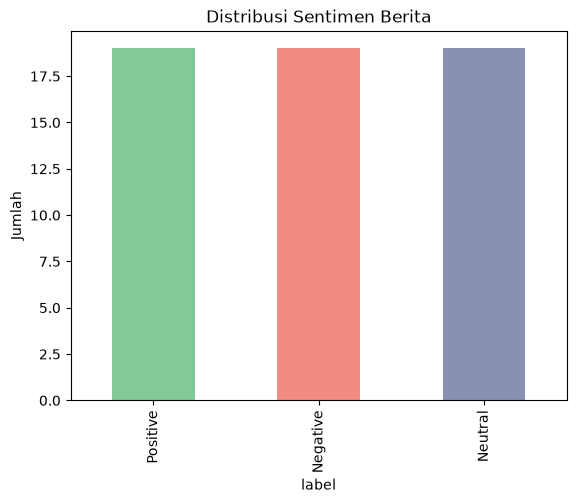

In [4]:
sentiment_counts = df['label'].value_counts()
print(sentiment_counts)

# Visualisasi sederhana
sentiment_counts.plot(kind='bar', color=['#81c995', '#f28b82', '#8892b0'])
plt.title('Distribusi Sentimen Berita')
plt.ylabel('Jumlah')
plt.show()

## 3. Data Preprocessing & Splitting
Membagi data menjadi *Training Set* (80%) dan *Testing Set* (20%).

In [5]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data Latih: {len(X_train)} baris")
print(f"Data Uji: {len(X_test)} baris")

Data Latih: 45 baris
Data Uji: 12 baris


## 4. Model Pipeline & Training
Kita akan menggunakan **TF-IDF (Term Frequency-Inverse Document Frequency)** untuk mengekstrak fitur numerik dari teks, dan algoritma **Naive Bayes** untuk klasifikasi teks. Ini dibungkus dalam satu buah *Pipeline*.

In [6]:
# Membuat Pipeline (TF-IDF -> Naive Bayes)
model = make_pipeline(
    TfidfVectorizer(lowercase=True, stop_words=None),
    MultinomialNB()
)

# Melatih model
model.fit(X_train, y_train)
print("Training Selesai!")

Training Selesai!


## 5. Model Evaluation
Menguji model pada *Testing Set* untuk melihat tingkat akurasinya.

In [7]:
y_pred = model.predict(X_test)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n")
print(classification_report(y_test, y_pred))

Akurasi Model: 0.4166666666666667

Laporan Klasifikasi:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         4
     Neutral       0.40      1.00      0.57         2
    Positive       0.50      0.50      0.50         6

    accuracy                           0.42        12
   macro avg       0.30      0.50      0.36        12
weighted avg       0.32      0.42      0.35        12



## 6. Inference (Prediksi Berita Baru)
Mari kita coba model ini dengan judul berita pasar saham yang baru!

In [8]:
def predict_sentiment(headlines):
    predictions = model.predict(headlines)
    for text, sentiment in zip(headlines, predictions):
        print(f"Berita  : '{text}'")
        print(f"Prediksi: {sentiment}\n")

# Percobaan
new_headlines = [
    "IHSG berhasil tembus rekor tertinggi tahun ini",
    "Ancaman resesi global membuat investor panik dan menarik dana",
    "Presiden umumkan hari libur bursa nasional"
]

predict_sentiment(new_headlines)

Berita  : 'IHSG berhasil tembus rekor tertinggi tahun ini'
Prediksi: Positive

Berita  : 'Ancaman resesi global membuat investor panik dan menarik dana'
Prediksi: Negative

Berita  : 'Presiden umumkan hari libur bursa nasional'
Prediksi: Neutral

